<a href="https://colab.research.google.com/github/Manthanmaheshwari/CEI_Assignment/blob/main/Week_04/Week%204%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Classification Study: Comparison of ANN and CNN Models
## Analyzing Architecture Differences and Performance Characteristics

This notebook serves as an educational walkthrough to explore:
- The fundamentals of classifying images using deep learning
- A direct comparison of performance between Dense Networks and Convolutional Networks
- The effect of network structure on capability
- How key training techniques influence final outcomes

Goal: Trace the entire deep learning implementation flow from data preprocessing to model evaluation.

# Objectives
Train and evaluate deep learning architectures on the CIFAR-10 image classification task.

We will construct:
1. A feedforward Artificial Neural Network (ANN)
2. A Convolutional Neural Network (CNN)

Following training, we will analyze:
- Overall accuracy scores
- Loss plots
- Generalization capabilities
- Optimization techniques (dropout, batch normalization, and data augmentation)

---
### Target Categories in CIFAR-10
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Data Retrieval
We import the CIFAR-10 collection, which consists of 60,000 color images sized 32 by 32 pixels across 3 color channels.
- Training subset: 50,000 samples
- Testing subset: 10,000 samples

In [4]:
# Load the CIFAR-10 dataset
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()

# Class labels in order
labels_list = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training data shape:", train_x.shape)
print("Testing data shape:", test_x.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2101s 12us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


## Inspecting Sample Dataset Images

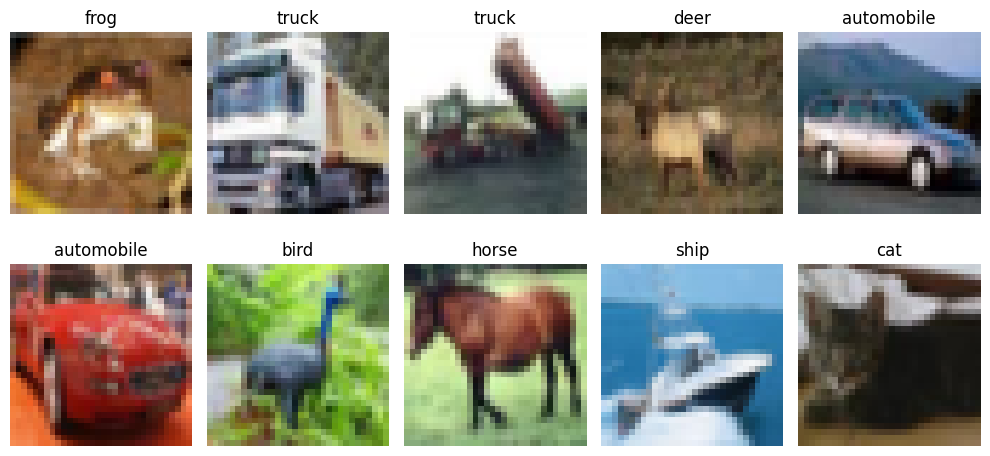

In [5]:
# Visualize a few sample images from the training set
plt.figure(figsize=(10, 5))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(train_x[idx])
    plt.title(labels_list[train_y[idx][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Data Preprocessing
We rescale the raw color channel inputs from [0, 255] to [0, 1] to normalize feature scales and optimize numerical stability.

In [6]:
# Scale pixel values to the range [0, 1]
train_x_norm = train_x / 255.0
test_x_norm = test_x / 255.0

# Flatten images for the ANN model
train_x_flat = train_x_norm.reshape(len(train_x_norm), -1)
test_x_flat = test_x_norm.reshape(len(test_x_norm), -1)

# Section 1: Feedforward Neural Network (ANN)
Standard fully connected layers expect flat vector inputs, meaning they lose spatial layouts and local pixel relationships.
This model serves as a baseline comparison.

In [7]:
# Construct the Dense Neural Network (ANN)
ann_classifier = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
ann_fit_history = ann_classifier.fit(
    train_x_flat, train_y,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2658 - loss: 2.0036 - val_accuracy: 0.3148 - val_loss: 1.8638
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3075 - loss: 1.8818 - val_accuracy: 0.3394 - val_loss: 1.8150
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3336 - loss: 1.8201 - val_accuracy: 0.3608 - val_loss: 1.7870
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3473 - loss: 1.7816 - val_accuracy: 0.3742 - val_loss: 1.7384
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3626 - loss: 1.7506 - val_accuracy: 0.4108 - val_loss: 1.6834
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3700 - loss: 1.7310 - val_accuracy: 0.3908 - val_loss: 1.6783
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3755 - loss: 1.7193 - val_accuracy: 0.4082 - val_loss: 1.6759
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3850 - loss: 1.6910 - val_accuracy: 0.

In [8]:
# Evaluate model accuracy on the test partition
ann_val_loss, ann_accuracy = ann_classifier.evaluate(test_x_flat, test_y)
print("ANN test set accuracy:", ann_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4278 - loss: 1.6220
ANN test set accuracy: 0.4277999997138977


# Section 2: Convolutional Neural Network (CNN)
CNNs process multidimensional grid arrays directly, preserving local structures via:
- Convolution operations
- Pooling functions
- Automatic local feature extraction
- Hierarchical representations

This makes CNNs far more suited for image processing tasks.

In [9]:
# Construct the Convolutional Neural Network (CNN)
cnn_classifier = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the CNN model
cnn_fit_history = cnn_classifier.fit(
    train_x_norm, train_y,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4728 - loss: 1.4838 - val_accuracy: 0.5598 - val_loss: 1.2295
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6128 - loss: 1.1113 - val_accuracy: 0.5662 - val_loss: 1.2185
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6760 - loss: 0.9339 - val_accuracy: 0.6404 - val_loss: 1.0279
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7125 - loss: 0.8268 - val_accuracy: 0.6884 - val_loss: 0.8980
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7458 - loss: 0.7304 - val_accuracy: 0.6566 - val_loss: 1.0096
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7683 - loss: 0.6607 - val_accuracy: 0.7104 - val_loss: 0.8383
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7940 - loss: 0.5945 - val_accuracy: 0.6856 - val_loss: 0.9743
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8109 - loss: 0.5375 - val_accuracy: 

In [10]:
# Evaluate model accuracy on the test partition
cnn_val_loss, cnn_accuracy = cnn_classifier.evaluate(test_x_norm, test_y)
print("CNN test set accuracy:", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7007 - loss: 0.9781
CNN test set accuracy: 0.7006999850273132


## Performance and Validation Comparison

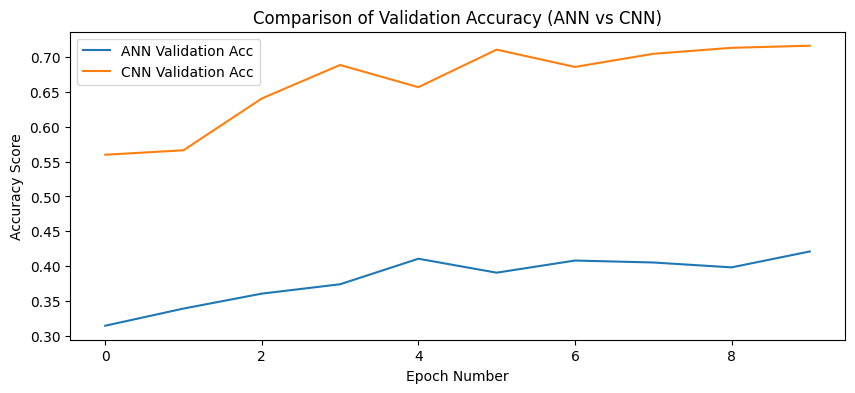

In [11]:
# Plot validation performance comparison
plt.figure(figsize=(10, 4))
plt.plot(ann_fit_history.history['val_accuracy'], label='ANN Validation Acc')
plt.plot(cnn_fit_history.history['val_accuracy'], label='CNN Validation Acc')
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy Score")
plt.title("Comparison of Validation Accuracy (ANN vs CNN)")
plt.legend()
plt.show()

# Section 3: Expanding Dataset Variety (Data Augmentation)
We introduce minor distortions to the inputs during training to mitigate overfitting and improve robust generalization.

In [12]:
# Setup data augmentation steps
aug_layers = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Build model incorporating augmentation layers
augmented_cnn = models.Sequential([
    aug_layers,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

augmented_cnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional training execution:
# augmented_cnn_history = augmented_cnn.fit(train_x_norm, train_y, epochs=10, validation_split=0.1)

# Baseline Comparison Table

In [13]:
# Display initial comparison results
metric_df = pd.DataFrame({
    "Model Type": ["ANN", "CNN"],
    "Test Accuracy Score": [ann_accuracy, cnn_accuracy]
})
metric_df

,Model Type,Test Accuracy Score
0,ANN,0.4278
1,CNN,0.7007


# Practice Exercises
Exercises to help solidify these concepts:

### Recommended Tasks
1. Add fully connected layers to the ANN design to inspect accuracy changes
2. Adjust the number of filters in the CNN architecture
3. Extend training length to 20 epochs
4. Integrate an EarlyStopping callback
5. Evaluate performance with data augmentation active

---
# Solutions to Practice Exercises

### Exercise 1: Expanding the ANN Structure
An additional fully connected layer with a size of 128 units and a dropout probability of 0.3 is inserted. This tests whether standard deep architectures can capture more distinct patterns from the serialized input vectors.

In [14]:
print("--- Task 1: Deeper ANN Model ---")
dense_mlp = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dense_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dense_mlp_history = dense_mlp.fit(
    train_x_flat, train_y,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

dense_mlp_loss, dense_mlp_accuracy = dense_mlp.evaluate(test_x_flat, test_y, verbose=0)
print(f"Deeper ANN Test Accuracy Score: {dense_mlp_accuracy:.4f}")

--- Task 1: Deeper ANN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2350 - loss: 2.0449 - val_accuracy: 0.3214 - val_loss: 1.8824
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2956 - loss: 1.9098 - val_accuracy: 0.3480 - val_loss: 1.8277
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3141 - loss: 1.8635 - val_accuracy: 0.3714 - val_loss: 1.7952
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3277 - loss: 1.8319 - val_accuracy: 0.3574 - val_loss: 1.7721
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3380 - loss: 1.8151 - val_accuracy: 0.3872 - val_loss: 1.7390
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3434 - loss: 1.7945 - val_accuracy: 0.3790 - val_loss: 1.7437
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3486 - loss: 1.7807 - val_accuracy: 0.3996 - val_loss: 1.7127
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3574 - loss: 1.7669 - val_accuracy: 0.

### Exercises 2, 3, and 4: CNN Architecture and Training Optimizations
The following additions were introduced:
- **Filters**: Configured sequential Conv2D layer widths to 32, 64, and 128 filters respectively to learn complex hierarchies.
- **Training Epochs**: Increased training cycles to 20 to allow convergence.
- **Early Stopping**: Integrated a validation loss early termination trigger with a patience value of 3 epochs.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

print("--- Tasks 2, 3, 4: Tuned CNN Model ---")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tuned_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

tuned_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tuned_cnn_history = tuned_cnn.fit(
    train_x_norm, train_y,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_callback],
    verbose=1
)

tuned_cnn_loss, tuned_cnn_accuracy = tuned_cnn.evaluate(test_x_norm, test_y, verbose=0)
print(f"Tuned CNN Test Accuracy Score: {tuned_cnn_accuracy:.4f}")

--- Tasks 2, 3, 4: Tuned CNN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4496 - loss: 1.5636 - val_accuracy: 0.3722 - val_loss: 1.9087
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5892 - loss: 1.1773 - val_accuracy: 0.5898 - val_loss: 1.1489
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6447 - loss: 1.0167 - val_accuracy: 0.6162 - val_loss: 1.1376
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6871 - loss: 0.8936 - val_accuracy: 0.6576 - val_loss: 0.9625
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7168 - loss: 0.8171 - val_accuracy: 0.6322 - val_loss: 1.1648
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7396 - loss: 0.7431 - val_accuracy: 0.6826 - val_loss: 0.9449
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7618 - loss: 0.6813 - val_accuracy: 0.7288 - val_loss: 0.8020
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7804 - loss: 0.6301 - val_accuracy: 

### Exercise 5: CNN Training with Augmentation Layers
Here we fit the previously compiled augmented model using 20 training epochs and the early stopping callback. The augmented input variations should reduce generalization error on the validation partition.

In [16]:
print("--- Task 5: Augmented CNN Training ---")
augmented_cnn_history = augmented_cnn.fit(
    train_x_norm, train_y,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_callback],
    verbose=1
)

augmented_cnn_loss, augmented_cnn_accuracy = augmented_cnn.evaluate(test_x_norm, test_y, verbose=0)
print(f"Augmented CNN Test Accuracy Score: {augmented_cnn_accuracy:.4f}")

--- Task 5: Augmented CNN Training ---
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3672 - loss: 1.7352 - val_accuracy: 0.4856 - val_loss: 1.3948
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4548 - loss: 1.5110 - val_accuracy: 0.5444 - val_loss: 1.2755
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4962 - loss: 1.4049 - val_accuracy: 0.5640 - val_loss: 1.2135
Augmented CNN Test Accuracy Score: 0.4856


### Comprehensive Architecture Comparison
A consolidated results overview showing test accuracy across all modified models.

In [17]:
summary_df = pd.DataFrame({
    "Model Architecture": ["Baseline ANN", "Deeper ANN", "Baseline CNN", "Upgraded CNN (20 Epochs + ES)", "Augmented CNN"],
    "Test Accuracy Score": [ann_accuracy, dense_mlp_accuracy, cnn_accuracy, tuned_cnn_accuracy, augmented_cnn_accuracy]
})
summary_df.sort_values(by="Test Accuracy Score", ascending=False, ignore_index=True)

,Model Architecture,Test Accuracy Score
0,Upgraded CNN (20 Epochs + ES),0.7146
1,Baseline CNN,0.7007
2,Augmented CNN,0.4856
3,Baseline ANN,0.4278
4,Deeper ANN,0.3935


# Summary and Key Takeaways
- The feedforward ANN compiles successfully, but its performance is restricted because spatial locality is discarded during flattening.
- The CNN retains geometric relationships, which yields higher accuracy metrics.
- Regularization methods such as dropout, batch normalization, and online dataset augmentation contribute to preventing overfitting.
- These experiments show typical deep learning pipelines used for classification tasks.